In [12]:
from google.colab import files
uploaded = files.upload()

Saving Test.csv to Test (2).csv
Saving Train.csv to Train (2).csv
Saving VariableDefinitions.csv to VariableDefinitions (2).csv


In [13]:

# Setup & Install
!pip install -q pandas scikit-learn matplotlib seaborn nltk openpyxl

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

print("✅ Setup complete!")

✅ Setup complete!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:

# LOAD DATA

train = pd.read_csv('Train.csv')
test  = pd.read_csv('Test.csv')
sample = pd.read_csv('SampleSubmission.csv')
var_def = pd.read_csv('VariableDefinitions.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape : {test.shape}")
print("\nCategories in Train:\n", train['category'].value_counts())

# Show unique categories (should be 5)
print("\nUnique categories:", train['category'].unique())

Train shape: (5151, 3)
Test shape : (1030, 2)

Categories in Train:
 category
Kitaifa      2000
michezo      1720
Biashara     1360
Kimataifa      54
Burudani       17
Name: count, dtype: int64

Unique categories: ['Kitaifa' 'Biashara' 'michezo' 'Kimataifa' 'Burudani']


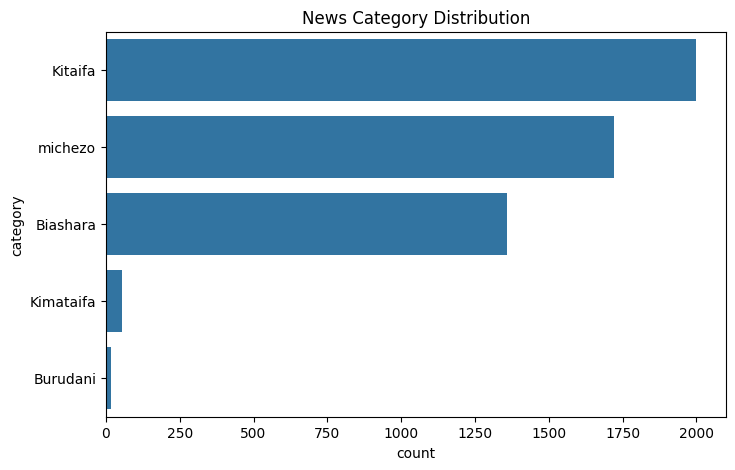

count     5151.000000
mean      2107.196273
std       1296.455505
min          1.000000
25%       1338.000000
50%       1812.000000
75%       2462.000000
max      17828.000000
Name: text_len, dtype: float64


In [15]:
# Category distribution
plt.figure(figsize=(8,5))
sns.countplot(y=train['category'], order=train['category'].value_counts().index)
plt.title('News Category Distribution')
plt.show()

# Text length stats
train['text_len'] = train['content'].astype(str).apply(len)
print(train['text_len'].describe())

In [16]:

# CLEANING (Swahili news)

swahili_stop = set([
    'na','ya','wa','la','za','kwa','ni','cha','katika','hiyo','hii','hapa','huko','kwenye',
    'kwamba','kama','lakini','au','ili','hivyo','pia','bado','baada','kabla','juu','chini',
    'ndani','nje','mara','sasa','leo','jana','juzi','kesho'
])

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@\S+|#\S+', '', text)      # remove urls
    text = re.sub(r'[^a-z\s]', ' ', text)                     # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [w for w in tokens if w not in swahili_stop]
    return ' '.join(tokens)

print("🧹 Cleaning texts...")
train['clean_content'] = train['content'].apply(clean_text)
test['clean_content']  = test['content'].apply(clean_text)

# Remove any empty rows
train = train[train['clean_content'].str.strip() != ''].reset_index(drop=True)

print("✅ Cleaning done!")

🧹 Cleaning texts...
✅ Cleaning done!


In [17]:
train_clean = train[['id', 'clean_content', 'category']].rename(columns={'clean_content':'content'})
test_clean  = test[['swahili_id', 'clean_content']].rename(columns={'swahili_id':'id', 'clean_content':'content'})

train_clean.to_csv('cleaned_train.csv', index=False)
test_clean.to_csv('cleaned_test.csv', index=False)

from google.colab import files
files.download('cleaned_train.csv')
files.download('cleaned_test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:

# BASELINE MODELS

X = train['clean_content']
y = train['category']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1,2), min_df=2)
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec   = vectorizer.transform(X_val)

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_vec, y_train)
pred_lr = lr.predict(X_val_vec)

# 2. Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
pred_nb = nb.predict(X_val_vec)

print("=== Logistic Regression ===")
print(classification_report(y_val, pred_lr))
print(f"Accuracy: {accuracy_score(y_val, pred_lr):.4f}\n")

print("=== Naive Bayes ===")
print(classification_report(y_val, pred_nb))
print(f"Accuracy: {accuracy_score(y_val, pred_nb):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

    Biashara       0.82      0.88      0.85       272
    Burudani       0.00      0.00      0.00         3
   Kimataifa       0.50      0.64      0.56        11
     Kitaifa       0.87      0.83      0.85       400
     michezo       0.96      0.93      0.95       344

    accuracy                           0.87      1030
   macro avg       0.63      0.66      0.64      1030
weighted avg       0.88      0.87      0.88      1030

Accuracy: 0.8748

=== Naive Bayes ===
              precision    recall  f1-score   support

    Biashara       0.85      0.72      0.78       272
    Burudani       0.00      0.00      0.00         3
   Kimataifa       0.00      0.00      0.00        11
     Kitaifa       0.75      0.90      0.82       400
     michezo       0.97      0.90      0.93       344

    accuracy                           0.84      1030
   macro avg       0.51      0.50      0.51      1030
weighted av

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:

# ADVANCED MODEL - LinearSVC

svc = LinearSVC(max_iter=2000, class_weight='balanced')
svc.fit(X_train_vec, y_train)
pred_svc = svc.predict(X_val_vec)

print("=== LinearSVC (Advanced) ===")
print(classification_report(y_val, pred_svc))
print(f"Accuracy: {accuracy_score(y_val, pred_svc):.4f}")

=== LinearSVC (Advanced) ===
              precision    recall  f1-score   support

    Biashara       0.82      0.83      0.82       272
    Burudani       0.00      0.00      0.00         3
   Kimataifa       0.75      0.27      0.40        11
     Kitaifa       0.85      0.86      0.85       400
     michezo       0.96      0.97      0.96       344

    accuracy                           0.88      1030
   macro avg       0.68      0.58      0.61      1030
weighted avg       0.87      0.88      0.87      1030

Accuracy: 0.8767


In [20]:

# FINAL PREDICTION & SUBMISSION
# Retrain on FULL train data with best model
X_full_vec = vectorizer.transform(train['clean_content'])
svc.fit(X_full_vec, train['category'])   # or use lr/nb if you prefer

# Predict on test
test_vec = vectorizer.transform(test['clean_content'])
test_pred = svc.predict(test_vec)

# Map to one-hot columns (exact SampleSubmission format)
cat_map = {
    'Kitaifa': 'kitaifa',
    'Kimataifa': 'kimataifa',
    'Biashara': 'biashara',
    'Michezo': 'michezo',
    'Burudani': 'burudani'
}

# Create submission
submission = sample.copy()  # keeps correct swahili_id order
submission.iloc[:, 1:] = 0   # reset all to 0

for idx, pred_cat in enumerate(test_pred):
    col_name = cat_map.get(pred_cat, pred_cat.lower())
    if col_name in submission.columns:
        submission.at[idx, col_name] = 1

# Save
submission.to_csv('submission.csv', index=False)
files.download('submission.csv')

print("🎉 Submission file ready! (exactly SampleSubmission format)")
print(submission.head())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 Submission file ready! (exactly SampleSubmission format)
                                 swahili_id  kitaifa  michezo  biashara  \
0  001dd47ac202d9db6624a5ff734a5e7dddafeaf2        1        0         0   
1  0043d97f7690e9bc02f0ed8bb2b260d1d44bad92        1        0         0   
2  00579c2307b5c11003d21c40c3ecff5e922c3fd8        0        1         0   
3  00868eeee349e286303706ef0ffd851f39708d37        0        0         1   
4  00a5cb12d3058dcf2e42f277eee599992db32412        1        0         0   

   kimataifa  burudani  
0          0         0  
1          0         0  
2          0         0  
3          0         0  
4          0         0  
